In [2]:
import gc
import torch

gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

import os
os.listdir(); os.chdir("/aiau010_scratch/azm0269/clover/")

from clover.utils.utils import notebook_line_magic
notebook_line_magic()

In [3]:
from clover.baselines.md3po import md3po_combined_rollouts


torch.cuda.is_available()

WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.12.1+cu130)
    Python  3.10.19 (you have 3.12.8)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


False

In [3]:
trajectories = torch.load("clover/data/ddpo/trajectories.pt")

In [9]:
reference_rollout = trajectories.get(1)
# for i in range(1, 2):
    # rollout = trajectories.get(i)
combined_rollout = md3po_combined_rollouts(
    reference_rollout=reference_rollout,
    trajectories=trajectories
)
    

In [12]:
combined_rollout['states'].shape

torch.Size([44, 50, 4, 64, 64])

Batch shape: (30, 4, 64, 64)


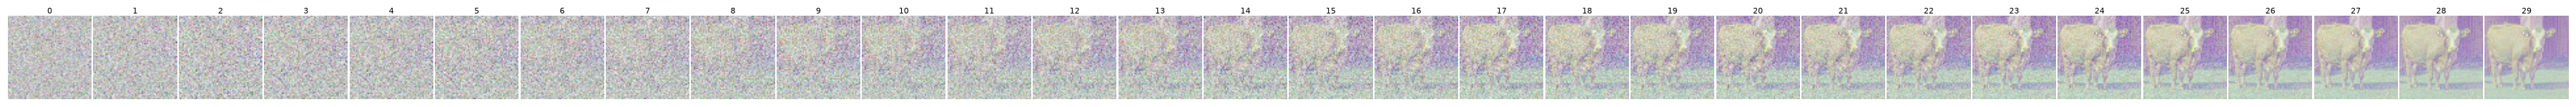

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def _to_rgba_uint8(frame_chw):
    """Convert a single frame from CHW tensor/array to HWC uint8 RGBA."""
    frame = frame_chw.detach().cpu().numpy() if hasattr(frame_chw, "detach") else np.asarray(frame_chw)

    # CHW -> HWC
    if frame.ndim == 3 and frame.shape[0] in (1, 3, 4):
        frame = np.transpose(frame, (1, 2, 0))

    # Force 4 channels for consistent RGBA display
    if frame.ndim == 3 and frame.shape[2] == 1:
        frame = np.repeat(frame, 4, axis=2)
    elif frame.ndim == 3 and frame.shape[2] == 3:
        alpha = np.ones((frame.shape[0], frame.shape[1], 1), dtype=frame.dtype)
        frame = np.concatenate([frame, alpha], axis=2)

    # Normalize to uint8
    if np.issubdtype(frame.dtype, np.floating):
        fmin, fmax = float(frame.min()), float(frame.max())
        if fmax > fmin:
            frame = (frame - fmin) / (fmax - fmin)
        else:
            frame = np.zeros_like(frame)
        frame = (frame * 255).astype(np.uint8)
    elif frame.dtype != np.uint8:
        frame = np.clip(frame, 0, 255).astype(np.uint8)

    return frame


def plot_batch_single_row(batch_tensor):
    """Plot a batch of shape (N, C, H, W) in one row."""
    n = int(batch_tensor.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.6), dpi=110)

    if n == 1:
        axes = [axes]

    for idx in range(n):
        rgba = _to_rgba_uint8(batch_tensor[idx])
        img = Image.fromarray(rgba, mode="RGBA")
        axes[idx].imshow(img)
        axes[idx].set_title(str(idx), fontsize=7, pad=2)
        axes[idx].axis("off")

    plt.subplots_adjust(wspace=0.02, hspace=0)
    plt.show()


batch = trajectories.get(1).get('state')[0]  # expected: (30, 4, 64, 64)
print("Batch shape:", tuple(batch.shape))
plot_batch_single_row(batch)

In [87]:
import cv2
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.spatial.distance import cosine
from typing import List

# Function to calculate SSIM
def calculate_ssim(imageA, imageB):
    # Convert images to grayscale
    grayA = cv2.cvtColor(imageA, cv2.COLOR_BGR2GRAY)
    grayB = cv2.cvtColor(imageB, cv2.COLOR_BGR2GRAY)
    
    # Compute SSIM between the two images
    score, _ = ssim(grayA, grayB, full=True)
    return score

@torch.no_grad()
def clip_features(images: list[Image.Image], device: torch.device | str | None = None) -> List:
    """Compute CLIP features for a list of images.
    """
    import open_clip

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load CLIP model
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-H-14', pretrained='laion2b_s32b_b79k')
    model = model.to(device).eval()
    tokenizer = open_clip.get_tokenizer('ViT-H-14')
    
    # Preprocess images
    processed_images = torch.stack([
        preprocess(image.convert("RGB")) for image in images
    ]).to(device)
    
    
    # Compute features
    autocast_device = "cuda" if device == "cuda" or str(device).startswith("cuda") else "cpu"
    with torch.autocast(autocast_device, enabled=autocast_device == "cuda"):
        image_features = model.encode_image(processed_images)
    
    # Normalize and compute similarity
    image_features /= image_features.norm(dim=-1, keepdim=True)
    
    return image_features.cpu()

def plot_image(img1, img2):
    pil_img1 = Image.fromarray(img1)
    pil_img2 = Image.fromarray(img2)

    fig, axes = plt.subplots(1, 2, figsize=(5, 5))

    axes[0].imshow(pil_img1)
    axes[0].axis("off")

    axes[1].imshow(pil_img2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [151]:
combined_rollout['images'].shape

torch.Size([2, 3, 512, 512])

In [154]:
trajectories[1]['images'].shape

torch.Size([1, 3, 512, 512])

SSIM between the reference image and the current image: 1.0000


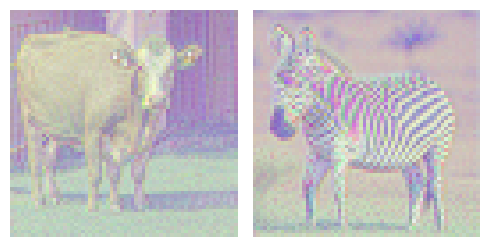

SSIM between the reference image and the current image: 1.0000


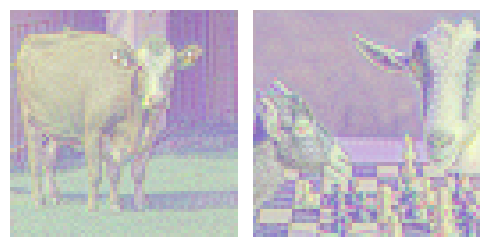

SSIM between the reference image and the current image: 1.0000


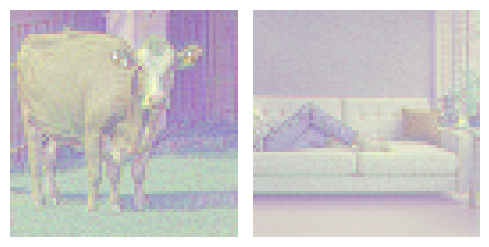

In [93]:
img = final_rollout_states.get(1)["final_state_tensor"]
reference_prompt = final_rollout_states.get(1)["prompt"]
reference_image = final_state_images[0]

for i in final_state_images[1:]:
    similarity = calculate_ssim(reference_image, )
    print(f"SSIM between the reference image and the current image: {similarity:.4f}")
    plot_image(reference_image, i)

SSIM between the two images: 0.1199


In [56]:
image_features = clip_features([Image.fromarray(img1), Image.fromarray(img2)])
similarity = 1 - cosine(image_features[0], image_features[1])
print(f"CLIP cosine similarity between the two images: {similarity:.4f}")

CLIP cosine similarity between the two images: 0.7326


In [58]:
trajectories.keys()

dict_keys([1, 2, 3, 4])